In [ ]:
Video Link: https://youtu.be/wWhsEFXGXs0

# Aspect-Based Sentiment Analysis (ABSA)
## Dataset: Amazon Electronics Reviews - McAuley Lab Amazon Reviews 2023

---

### What is ABSA?
When someone reviews a product, they usually talk about specific things - how long the charge lasts, whether the speakers sound tinny, if the price feels fair. Standard sentiment analysis ignores all of that and just says "positive" or "negative" for the whole review. That's a problem.

ABSA (Aspect-Based Sentiment Analysis) goes deeper. It figures out **what feature** someone is talking about and **how they feel** about that specific feature. So a review like:

> "Speakers sound incredible but the wifi drops every ten minutes"
> sound: **positive** | connectivity: **negative**

It gets broken down into two separate opinions instead of being averaged into one.

### What this project does
An end-to-end ABSA pipeline that takes raw Amazon electronics reviews and:
1. Cleans and splits them into individual sentences
2. Labels each sentence with an aspect (battery, camera, sound, etc.) and sentiment
3. Extracts semantic embeddings using **DistilBERT**
4. Trains custom **deep neural networks** to predict aspect and sentiment
5. Compares the trained model against a **zero-shot baseline** (BART-MNLI) to measure how much value the training adds
6. Uses LLM model as an independent judge that cross-validates predictions

### Pipeline Overview
| Step | Description |
|------|-------------|
| 1 | Data collection from Amazon Reviews 2023 |
| 2 | Data exploration & inspection |
| 3 | Data cleaning & preprocessing |
| 4 | Text cleaning & sentence tokenization |
| 5 | Aspect labeling (keyword-based) |
| 6 | Sentiment labeling (rating-based) |
| 7 | Save cleaned dataset |
| 8 | Exploratory data analysis |
| 9 | Dataset balancing (aspect × sentiment) |
| 10 | DistilBERT embedding extraction |
| 11 | DNN model training |
| 12 | Binary sentiment model |
| 13 | Evaluation & error analysis |
| 14 | Baseline comparison (zero-shot) |
| 15 | LLM integration (Llama 3 as judge) |
| 16 | Ethical considerations |

## Step 1: Data Collection
Raw electronics reviews are streamed **line-by-line** from the McAuley-Lab Amazon Reviews 2023 dataset on HuggingFace.
The full dataset is massive, so instead of downloading the whole thing, streamed it line-by-line and grab the first 50,000 electronics reviews.

In [1]:
import requests
import json
import pandas as pd

# Amazon Electronics Reviews 2023 - McAuley Lab Dataset
reviews_url = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Electronics.jsonl"
max_reviews = 50000  # 50,000 reviews is sufficient for ABSA training

raw_records = []

try:
    with requests.get(reviews_url, stream=True) as r:
        for i, line in enumerate(r.iter_lines()):
            if i >= max_reviews:
                break
            if line:
                raw_records.append(json.loads(line))
except Exception as e:
    print(f"Error downloading data: {e}")

# Convert to DataFrame
reviews_df = pd.DataFrame(raw_records)
print(f"Loaded {reviews_df.shape[0]} reviews with {reviews_df.shape[1]} columns")
print("Columns:", reviews_df.columns.tolist())
print(reviews_df.head(3))

Loaded 50000 reviews with 10 columns
Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
   rating                                    title  \
0     3.0        Smells like gasoline! Going back!   
1     1.0  Didn’t work at all lenses loose/broken.   
2     5.0                               Excellent!   

                                                text  \
0  First & most offensive: they reek of gasoline ...   
1  These didn’t work. Idk if they were damaged in...   
2  I love these. They even come with a carry case...   

                                              images        asin parent_asin  \
0  [{'small_image_url': 'https://m.media-amazon.c...  B083NRGZMM  B083NRGZMM   
1                                                 []  B07N69T6TM  B07N69T6TM   
2                                                 []  B01G8JO5F2  B01G8JO5F2   

                        user_id      timestamp  helpful_vote  \
0  AF

## Step 2: Data Exploration & Inspection
Examining column types, shapes, and missing values to understand what we are working with before any cleaning.

In [2]:
# Display data types and shape
print(f"Dataset shape: {reviews_df.shape}")
print("\nData types:")
print(reviews_df.dtypes)

# Check for missing values
print("\nMissing values per column:")
print(reviews_df.isnull().sum())

# Preview a few rows
print("\nFirst 3 rows:")
print(reviews_df[['text', 'rating', 'verified_purchase']].head(3))

Dataset shape: (50000, 10)

Data types:
rating               float64
title                 object
text                  object
images                object
asin                  object
parent_asin           object
user_id               object
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object

Missing values per column:
rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

First 3 rows:
                                                text  rating  \
0  First & most offensive: they reek of gasoline ...     3.0   
1  These didn’t work. Idk if they were damaged in...     1.0   
2  I love these. They even come with a carry case...     5.0   

   verified_purchase  
0               True  
1               True  
2               True  


## Step 3: Data Cleaning & Preprocessing
Retaining only the 5 columns relevant to ABSA: review text, title, star rating, verified purchase status, and helpful votes.
Rows with missing text or ratings are dropped, and exact duplicate reviews are removed.

In [3]:
# Keep only relevant columns for ABSA
reviews_df = reviews_df[['text', 'title', 'rating', 'verified_purchase', 'helpful_vote']]

# Check for nulls
print("Missing values per column:")
print(reviews_df.isnull().sum())

# Drop rows with missing text or rating
reviews_df = reviews_df.dropna(subset=['text', 'rating'])

# Remove duplicate reviews
reviews_df = reviews_df.drop_duplicates(subset=['text'])

print(f"\nAfter removing nulls and duplicates: {reviews_df.shape}")

Missing values per column:
text                 0
title                0
rating               0
verified_purchase    0
helpful_vote         0
dtype: int64

After removing nulls and duplicates: (47265, 5)


## Step 4: Text Cleaning & Sentence Tokenization
Reviews are messy, they contain HTML tags, URLs, random special characters. Cleaning all of that out, then split each review into individual sentences using NLTK.

In [4]:
import re
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize

def clean_text(text):
    """Remove noise from review text."""
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)                   # remove HTML tags
    text = re.sub(r'http\S+', '', text)                 # remove URLs
    text = re.sub(r'[^a-z0-9\s.,!?]', '', text)         # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()            # remove extra spaces
    return text

# Apply text cleaning
reviews_df['clean_text'] = reviews_df['text'].apply(clean_text)

# Split each review into sentences
reviews_df['sentences'] = reviews_df['clean_text'].apply(sent_tokenize)
reviews_df = reviews_df.explode('sentences').reset_index(drop=True)

# Remove very short sentences
reviews_df = reviews_df[reviews_df['sentences'].str.split().str.len() >= 5]

print(f"Total sentences after tokenization: {reviews_df.shape[0]}")
print("\nSample cleaned sentences:")
print(reviews_df['sentences'].head(5).to_string())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Total sentences after tokenization: 183654

Sample cleaned sentences:
0    first most offensive they reek of gasoline so ...
1            second the phone adapter is useless asis.
2    mine was not drilled far enough to be able to ...
3                       it just slipped slid all over.
4    stupid me putting the adapter together first w...


## Step 5: Aspect Labeling
The Amazon dataset doesn't come with aspect labels, created them using keyword matching. For each sentence, checked if it contains words associated with one of 8 electronics-specific aspects.


In [5]:
# Electronics-specific aspect keywords — uppercase signals constant
ASPECT_KEYWORDS = {
    'battery':      ['battery', 'charge', 'charging', 'power', 'drain'],
    'display':      ['screen', 'display', 'resolution', 'brightness'],
    'performance':  ['speed', 'fast', 'slow', 'lag', 'performance', 'processor'],
    'sound':        ['sound', 'audio', 'speaker', 'volume', 'noise', 'bass'],
    'design':       ['design', 'build', 'material', 'size', 'weight'],
    'camera':       ['camera', 'photo', 'picture', 'lens', 'video', 'zoom'],
    'connectivity': ['wifi', 'bluetooth', 'connection', 'signal', 'network'],
    'price':        ['price', 'cost', 'expensive', 'cheap', 'value', 'worth']
}

def label_aspect(sentence):
    """Assign aspect label based on keyword matching."""
    for aspect, keywords in ASPECT_KEYWORDS.items():
        if any(kw in sentence.lower() for kw in keywords):
            return aspect
    return 'general'  # no aspect keyword found

reviews_df['aspect'] = reviews_df['sentences'].apply(label_aspect)

print("Aspect distribution (before balancing):")
print(reviews_df['aspect'].value_counts())

Aspect distribution (before balancing):
aspect
general         118839
battery          13085
sound            12623
camera           11374
price             8077
design            6548
display           5330
performance       4098
connectivity      3680
Name: count, dtype: int64


## Step 6: Sentiment Labeling
Assigning sentiment labels based on the review's overall star rating:

- **4-5 stars** -> positive
- **3 stars** -> neutral
- **1-2 stars** -> negative


In [6]:
def map_sentiment(rating):
    """Map star rating to sentiment label."""
    if rating >= 4:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'

reviews_df['sentiment'] = reviews_df['rating'].apply(map_sentiment)

print("Sentiment distribution (before balancing):")
print(reviews_df['sentiment'].value_counts())
print("\nSentiment % breakdown:")
print(reviews_df['sentiment'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Sentiment distribution (before balancing):
sentiment
positive    143412
negative     24064
neutral      16178
Name: count, dtype: int64

Sentiment % breakdown:
sentiment
positive    78.1%
negative    13.1%
neutral      8.8%
Name: proportion, dtype: object


## Step 7: Save Cleaned Dataset
The cleaned, labeled dataset is saved to CSV for reproducibility.
At this point each row represents one sentence with its aspect and sentiment label.

In [7]:
# Keep only relevant columns for final dataset
reviews_final_df = reviews_df[['sentences', 'aspect', 'sentiment']].reset_index(drop = True)

# Save the final dataset to CSV
reviews_final_df.to_csv('absa_electronics_clean.csv', index = False)

print(f"Final dataset shape: {reviews_final_df.shape}")
print(reviews_final_df.head(10))

Final dataset shape: (183654, 3)
                                           sentences   aspect sentiment
0  first most offensive they reek of gasoline so ...  general   neutral
1          second the phone adapter is useless asis.  general   neutral
2  mine was not drilled far enough to be able to ...  general   neutral
3                     it just slipped slid all over.  general   neutral
4  stupid me putting the adapter together first w...  general   neutral
5  i had to come back here to the website which w...  general   neutral
6                  third the tripod is also useless.  general   neutral
7  i would not trust the ios to hold my 1600 phon...  general   neutral
8              its just inefficient for the job imo.  general   neutral
9  third in order to try to give an honest review...  general   neutral


## Step 8: Exploratory Data Analysis (EDA)
Before balancing, visualizing both distributions to understand the raw dataset characteristics
and identify imbalances that need to be addressed before training.

=== Dataset Statistics ===
Total sentences:  183654

Aspect distribution:
aspect
general         118839
battery          13085
sound            12623
camera           11374
price             8077
design            6548
display           5330
performance       4098
connectivity      3680
Name: count, dtype: int64

Sentiment distribution:
sentiment
positive    143412
negative     24064
neutral      16178
Name: count, dtype: int64


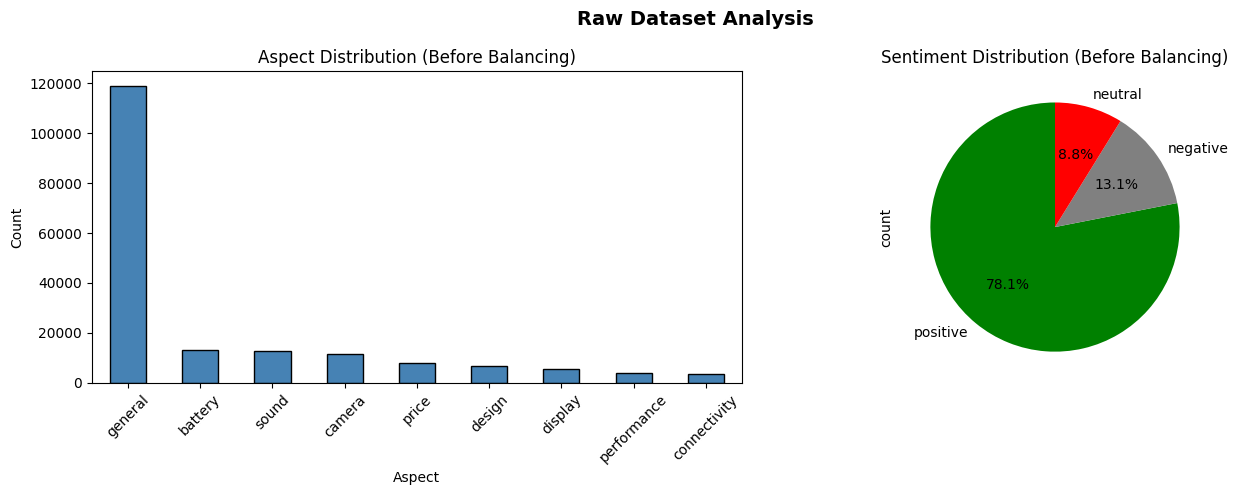

In [8]:
import matplotlib.pyplot as plt

# Print dataset statistics
print("=== Dataset Statistics ===")
print(f"Total sentences:  {reviews_final_df.shape[0]}")
print(f"\nAspect distribution:\n{reviews_final_df['aspect'].value_counts()}")
print(f"\nSentiment distribution:\n{reviews_final_df['sentiment'].value_counts()}")

# Visualize distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Aspect distribution bar chart
reviews_final_df['aspect'].value_counts().plot(
    kind='bar', ax=ax1, color='steelblue', edgecolor='black'
)
ax1.set_title('Aspect Distribution (Before Balancing)', fontsize=12)
ax1.set_xlabel('Aspect')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Sentiment distribution pie chart
reviews_final_df['sentiment'].value_counts().plot(
    kind='pie', ax=ax2, autopct='%1.1f%%',
    colors=['green', 'gray', 'red'], startangle=90
)
ax2.set_title('Sentiment Distribution (Before Balancing)', fontsize=12)

plt.suptitle('Raw Dataset Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Observations
- **Aspect imbalance:** general sentences dominates, these should be removed as they carry no useful aspect signal  
- **Sentiment imbalance:** ~78% positive, reflects Amazon's natural review bias. A model trained without balancing would predict "positive" for everything and still achieve 78% accuracy

## Step 9: Dataset Balancing
Removing **general** sentences entirely, then balance at the **aspect × sentiment combination** level.

In [9]:
# Remove 'general' aspect sentences
reviews_balanced_df = reviews_final_df[reviews_final_df['aspect'] != 'general'].copy()
print(f"After removing 'general': {reviews_balanced_df.shape}")

# Balance at the aspect × sentiment combination level
reviews_balanced_df = (
    reviews_balanced_df
    .groupby(['aspect', 'sentiment'], group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), 500), random_state=42))
    .reset_index(drop=True)
)

print("\nAspect × Sentiment distribution:")
print(reviews_balanced_df.groupby(['aspect', 'sentiment']).size().unstack(fill_value=0))

print(f"\nAspect distribution:")
print(reviews_balanced_df['aspect'].value_counts())

print(f"\nSentiment distribution:")
print(reviews_balanced_df['sentiment'].value_counts())

print(f"\nFinal balanced dataset: {reviews_balanced_df.shape}")

# Save balanced dataset
reviews_balanced_df.to_csv('absa_electronics_balanced.csv', index=False)
print("\nBalanced dataset saved.")
print(reviews_balanced_df.head(10))

After removing 'general': (64815, 3)

Aspect × Sentiment distribution:
sentiment     negative  neutral  positive
aspect                                   
battery            500      500       500
camera             500      500       500
connectivity       500      329       500
design             500      500       500
display            500      495       500
performance        439      312       500
price              500      500       500
sound              500      500       500

Aspect distribution:
aspect
battery         1500
camera          1500
design          1500
sound           1500
price           1500
display         1495
connectivity    1329
performance     1251
Name: count, dtype: int64

Sentiment distribution:
sentiment
positive    4000
negative    3939
neutral     3636
Name: count, dtype: int64

Final balanced dataset: (11575, 3)

Balanced dataset saved.
                                           sentences   aspect sentiment
0  the meikes are higher quality, but don

/tmp/ipykernel_27350/2368432026.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), 500), random_state=42))


## Step 10: DistilBERT Embedding Extraction

In [10]:
import torch
import numpy as np
import random
from transformers import DistilBertTokenizer, DistilBertModel

# Set all seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Load balanced dataset (lets me restart from this point without rerunning Steps 1-9)
reviews_balanced_df = pd.read_csv('absa_electronics_balanced.csv')
print(f"Loaded balanced dataset: {reviews_balanced_df.shape}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
distilbert_model = DistilBertModel.from_pretrained('distilbert-base-uncased').to(device)
distilbert_model.eval()

def extract_sentence_embeddings(sentences, batch_size=32):
    """Extract 768-dim CLS token embeddings from DistilBERT."""
    sentences = sentences.reset_index(drop=True)
    all_embeddings = []
    for i in range(0, len(sentences), batch_size):
        batch = list(sentences.iloc[i:i+batch_size])
        tokens = distilbert_tokenizer(
            batch,
            max_length=64,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        tokens = {k: v.to(device) for k, v in tokens.items()}
        with torch.no_grad():
            outputs = distilbert_model(**tokens)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)
        if (i // batch_size) % 16 == 0:
            print(f"  Processed {i}/{len(sentences)} sentences...")
    return np.vstack(all_embeddings)

print("Extracting DistilBERT embeddings...")
sentence_embeddings = extract_sentence_embeddings(reviews_balanced_df['sentences'])
np.save('embeddings.npy', sentence_embeddings)
print(f"Embeddings saved — shape: {sentence_embeddings.shape}")

Loaded balanced dataset: (11575, 3)
Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting DistilBERT embeddings...
  Processed 0/11575 sentences...
  Processed 512/11575 sentences...
  Processed 1024/11575 sentences...
  Processed 1536/11575 sentences...
  Processed 2048/11575 sentences...
  Processed 2560/11575 sentences...
  Processed 3072/11575 sentences...
  Processed 3584/11575 sentences...
  Processed 4096/11575 sentences...
  Processed 4608/11575 sentences...
  Processed 5120/11575 sentences...
  Processed 5632/11575 sentences...
  Processed 6144/11575 sentences...
  Processed 6656/11575 sentences...
  Processed 7168/11575 sentences...
  Processed 7680/11575 sentences...
  Processed 8192/11575 sentences...
  Processed 8704/11575 sentences...
  Processed 9216/11575 sentences...
  Processed 9728/11575 sentences...
  Processed 10240/11575 sentences...
  Processed 10752/11575 sentences...
  Processed 11264/11575 sentences...
Embeddings saved — shape: (11575, 768)


## Step 11: Label Encoding & Train/Test Split
Before training, encoding the aspect and sentiment labels as integers and split the data 80/20. The split is **stratified by aspect** so each category is proportionally represented in both train and test sets

In [11]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

tf.random.set_seed(42)
np.random.seed(42)

# Load saved embeddings
sentence_embeddings = np.load('embeddings.npy')
print(f"Embeddings loaded: {sentence_embeddings.shape}")

# Encode labels to integers
aspect_encoder = LabelEncoder()
sentiment_encoder = LabelEncoder()

y_aspect = aspect_encoder.fit_transform(reviews_balanced_df['aspect'])
y_sentiment = sentiment_encoder.fit_transform(reviews_balanced_df['sentiment'])

n_aspects = len(aspect_encoder.classes_)
n_sentiments = len(sentiment_encoder.classes_)

print(f"Aspect classes ({n_aspects}):    {aspect_encoder.classes_}")
print(f"Sentiment classes ({n_sentiments}): {sentiment_encoder.classes_}")

# Stratified 80/20 split — ensures balanced representation in test set
X_train, X_test, ya_train, ya_test, ys_train, ys_test = train_test_split(
    sentence_embeddings, y_aspect, y_sentiment,
    test_size = 0.2,
    random_state = 42,
    stratify=y_aspect
)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")

Embeddings loaded: (11575, 768)
Aspect classes (8):    ['battery' 'camera' 'connectivity' 'design' 'display' 'performance'
 'price' 'sound']
Sentiment classes (3): ['negative' 'neutral' 'positive']

Train set: (9260, 768)
Test set:  (2315, 768)


## Step 12: DNN Training - Aspect Classifier
Training two separate DNNs, one for aspect, one for sentiment. Both sit on top of the DistilBERT embeddings.

The training uses:
- **EarlyStopping** : stops when validation loss hasn't improved for 5 epochs and restores the best weights
- **ReduceLROnPlateau** : halves the learning rate when progress stalls for 3 epochs
- **BatchNormalization** : stabilizes the gradient flow between layers
- **Dropout(0.4)** : randomly disables 40% of neurons each step to prevent overfitting
- **L2 regularization** : penalizes large weights to reduce overfitting further


In [12]:
# Aspect Classification DNN — 8-class softmax output
aspect_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(sentence_embeddings.shape[1],)),
    tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(n_aspects, activation='softmax')
], name='aspect_classifier')

aspect_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aspect_model.summary()

# Fresh callbacks
print("\nTraining Aspect Model...")
aspect_history = aspect_model.fit(
    X_train, ya_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    shuffle=True,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    ]
)

Model: "aspect_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 530,184 (2.02 MB)

 Trainable params: 528,648 (2.02 MB)

 Non-trainable params: 1,536 (6.00 KB)


Training Aspect Model...
Epoch 1/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.5590 - loss: 2.2137 - val_accuracy: 0.6814 - val_loss: 1.6648 - learning_rate: 0.0010
Epoch 2/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6691 - loss: 1.7002 - val_accuracy: 0.7376 - val_loss: 1.4316 - learning_rate: 0.0010
Epoch 3/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7111 - loss: 1.4920 - val_accuracy: 0.7333 - val_loss: 1.3819 - learning_rate: 0.0010
Epoch 4/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7265 - loss: 1.3598 - val_accuracy: 0.7397 - val_loss: 1.2446 - learning_rate: 0.0010
Epoch 5/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7483 - loss: 1.2494 - val_accuracy: 0.7484 - val_loss: 1.2364 - learning_rate: 0.0010
Epoch 6/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7501 - loss: 1.1806 - val_accuracy: 0.7559 - val_loss: 1.1256 - learning_rate: 0.0010
Epoch 7/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accurac

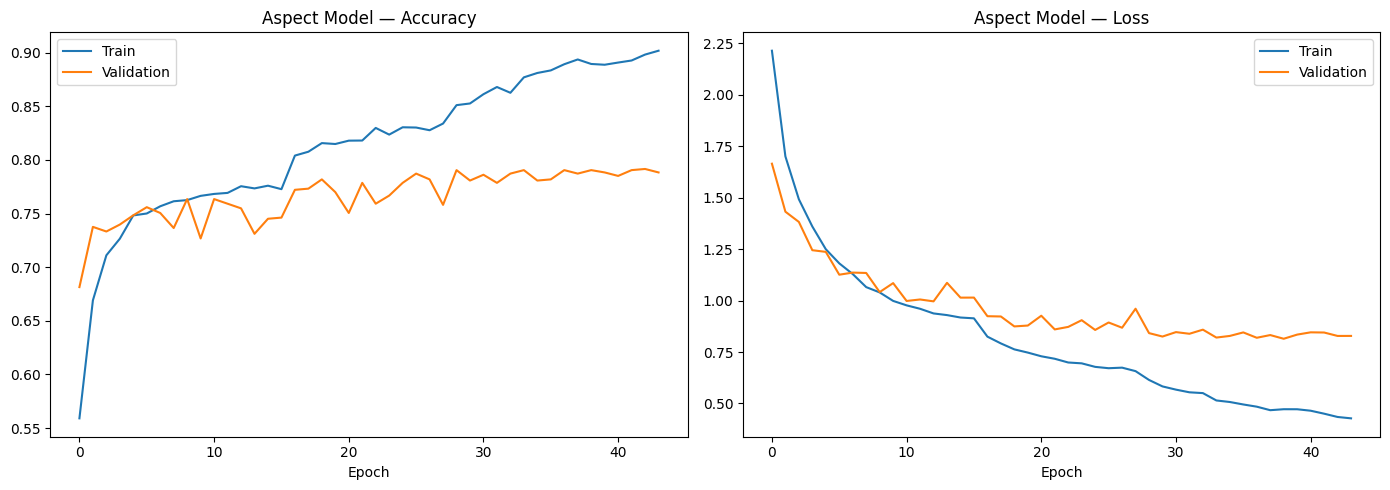

In [13]:
# plotting the graph
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(aspect_history.history['accuracy'], label='Train')
ax1.plot(aspect_history.history['val_accuracy'], label='Validation')
ax1.set_title('Aspect Model — Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(aspect_history.history['loss'], label='Train')
ax2.plot(aspect_history.history['val_loss'], label='Validation')
ax2.set_title('Aspect Model — Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
plt.tight_layout()
plt.show()

## Step 13: Binary Sentiment Model

In [14]:
# Drop neutral
reviews_binary_df = reviews_balanced_df[reviews_balanced_df['sentiment'] != 'neutral'].copy()

sentiment_encoder_binary = LabelEncoder()
reviews_binary_df['sentiment_label'] = sentiment_encoder_binary.fit_transform(
    reviews_binary_df['sentiment']
)
print("Binary sentiment classes:", sentiment_encoder_binary.classes_)

# Align embeddings with binary subset
embeddings_binary = sentence_embeddings[reviews_balanced_df['sentiment'] != 'neutral']

# Stratified split for balanced pos/neg in test set
X_train_b, X_test_b, ys_train_b, ys_test_b = train_test_split(
    embeddings_binary,
    reviews_binary_df['sentiment_label'].values,
    test_size=0.2,
    random_state=42,
    stratify=reviews_binary_df['sentiment_label'].values
)
print(f"Binary dataset — Train: {X_train_b.shape}, Test: {X_test_b.shape}")

# Binary Sentiment DNN
sentiment_model_binary = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(sentence_embeddings.shape[1],)),
    tf.keras.layers.Dense(512, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid')
], name='binary_sentiment_classifier')

sentiment_model_binary.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

sentiment_model_binary.summary()

# Fresh callbacks - separate from aspect model
print("\nTraining Binary Sentiment Model...")
sentiment_history_binary = sentiment_model_binary.fit(
    X_train_b, ys_train_b,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    ]
)

Binary sentiment classes: ['negative' 'positive']
Binary dataset — Train: (6351, 768), Test: (1588, 768)


Model: "binary_sentiment_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 528,385 (2.02 MB)

 Trainable params: 526,849 (2.01 MB)

 Non-trainable params: 1,536 (6.00 KB)


Training Binary Sentiment Model...
Epoch 1/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.6499 - loss: 1.4769 - val_accuracy: 0.7453 - val_loss: 1.2433 - learning_rate: 0.0010
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6857 - loss: 1.2452 - val_accuracy: 0.7311 - val_loss: 1.1010 - learning_rate: 0.0010
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7162 - loss: 1.1032 - val_accuracy: 0.7437 - val_loss: 1.0090 - learning_rate: 0.0010
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7283 - loss: 0.9957 - val_accuracy: 0.7248 - val_loss: 0.9358 - learning_rate: 0.0010
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7235 - loss: 0.9103 - val_accuracy: 0.7374 - val_loss: 0.8633 - learning_rate: 0.0010
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7356 - loss: 0.8315 - val_accuracy: 0.7343 - val_loss: 0.8173 - learning_rate: 0.0010
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

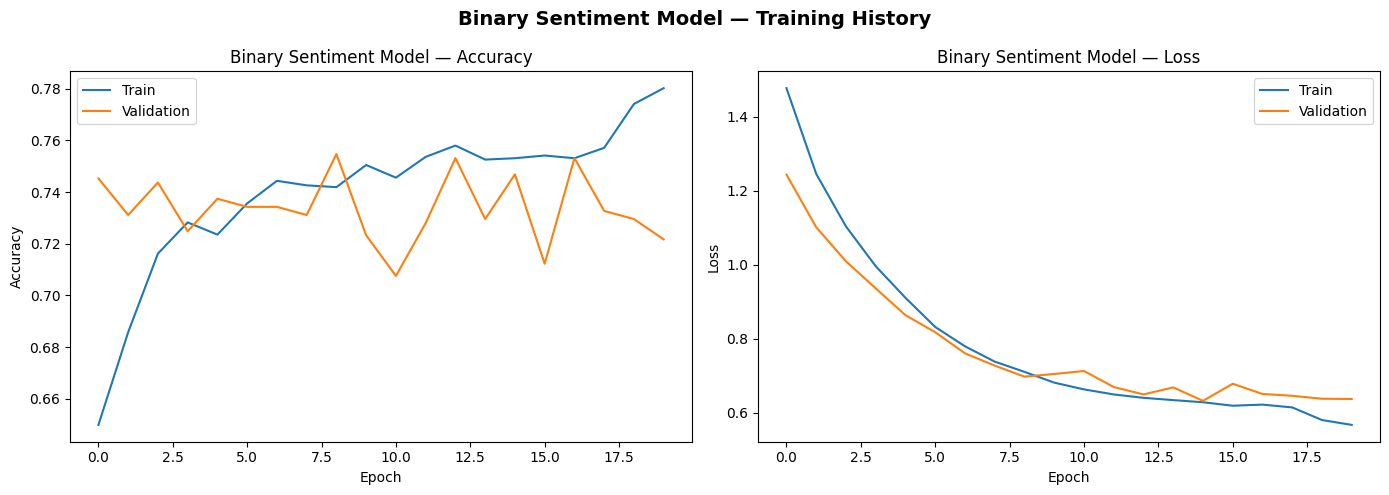

In [15]:
# Binary Sentiment Model — Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(sentiment_history_binary.history['accuracy'], label='Train')
ax1.plot(sentiment_history_binary.history['val_accuracy'], label='Validation')
ax1.set_title('Binary Sentiment Model — Accuracy', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(sentiment_history_binary.history['loss'], label='Train')
ax2.plot(sentiment_history_binary.history['val_loss'], label='Validation')
ax2.set_title('Binary Sentiment Model — Loss', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.suptitle('Binary Sentiment Model — Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 14: Model Evaluation
Both models are evaluated on the held-out test set (20% of data).
Confusion matrices reveal which aspects are most/least confused with each other.

=== Aspect Model ===
Test Accuracy: 0.7676
Test Loss:     0.8950
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

Classification Report:
              precision    recall  f1-score   support

     battery       0.79      0.73      0.76       300
      camera       0.77      0.78      0.77       300
connectivity       0.76      0.82      0.79       266
      design       0.75      0.62      0.68       300
     display       0.81      0.77      0.79       299
 performance       0.68      0.75      0.72       250
       price       0.80      0.84      0.82       300
       sound       0.77      0.84      0.81       300

    accuracy                           0.77      2315
   macro avg       0.77      0.77      0.77      2315
weighted avg       0.77      0.77      0.77      2315


=== Binary Sentiment Model ===
Test Accuracy: 0.7122
Test Loss:     0.6857
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

Classification Report:
              precision    recall  f1-score   support

    negative       0.72    

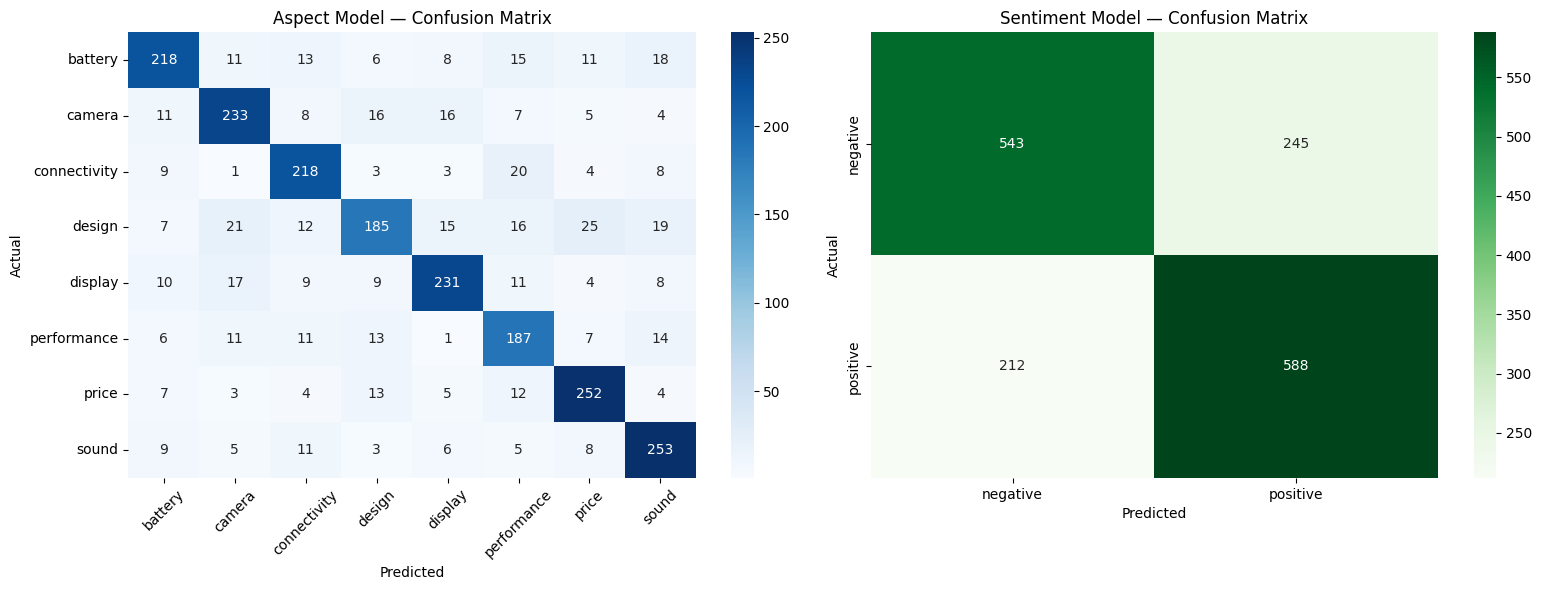

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Aspect Model Evaluation
print("=== Aspect Model ===")
aspect_loss, aspect_acc = aspect_model.evaluate(X_test, ya_test, verbose=0)
print(f"Test Accuracy: {aspect_acc:.4f}")
print(f"Test Loss:     {aspect_loss:.4f}")
ya_pred = aspect_model.predict(X_test).argmax(axis=1)
print("\nClassification Report:")
print(classification_report(ya_test, ya_pred, target_names=aspect_encoder.classes_))

# Sentiment Model Evaluation
print("\n=== Binary Sentiment Model ===")
sent_loss, sent_acc = sentiment_model_binary.evaluate(X_test_b, ys_test_b, verbose=0)
print(f"Test Accuracy: {sent_acc:.4f}")
print(f"Test Loss:     {sent_loss:.4f}")
ys_pred = (sentiment_model_binary.predict(X_test_b) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(ys_test_b, ys_pred, target_names=sentiment_encoder_binary.classes_))

# Confusion Matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

cm_aspect = confusion_matrix(ya_test, ya_pred)
sns.heatmap(cm_aspect, annot=True, fmt='d', ax=ax1,
            xticklabels=aspect_encoder.classes_,
            yticklabels=aspect_encoder.classes_,
            cmap='Blues')
ax1.set_title('Aspect Model — Confusion Matrix', fontsize=12)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.tick_params(axis='x', rotation=45)

cm_sent = confusion_matrix(ys_test_b, ys_pred)
sns.heatmap(cm_sent, annot=True, fmt='d', ax=ax2,
            xticklabels=sentiment_encoder_binary.classes_,
            yticklabels=sentiment_encoder_binary.classes_,
            cmap='Greens')
ax2.set_title('Sentiment Model — Confusion Matrix', fontsize=12)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [17]:
# Sentiment Accuracy Broken Down by Aspect
binary_df = reviews_balanced_df[reviews_balanced_df['sentiment'] != 'neutral'].reset_index(drop=True)

train_df,test_df = train_test_split(
    binary_df,
    test_size = 0.2,
    random_state = 42,
    stratify = binary_df['sentiment']
)

# pull the correct aspect and sentence for each test sample
test_aspects_for_sentiment = test_df['aspect'].values
test_sentences_for_sentiment = test_df['sentences'].values


correct_sentiment = (ys_pred.flatten() == ys_test_b)

print("Sentiment Accuracy by Aspect:")
print("-" * 80)
print(f"  {'Aspect':<15} {'Accuracy':<10} {'Correct':<10} {'Total':<10}")

aspect_accs = {}
for aspect in sorted(test_df['aspect'].unique()):
    mask = test_aspects_for_sentiment == aspect
    total = mask.sum()
    if total > 0:
        correct = correct_sentiment[mask].sum()
        acc = correct / total
        aspect_accs[aspect] = acc
        bar = "█" * int(acc * 30)
        print(f"  {aspect:<15} {acc:.2%}  {correct:<10} {total:<10} {bar}")

best = max(aspect_accs, key=aspect_accs.get)
worst = min(aspect_accs, key=aspect_accs.get)
print(f"\nBest:  {best} ({aspect_accs[best]:.2%})")
print(f"Worst: {worst} ({aspect_accs[worst]:.2%})")

Sentiment Accuracy by Aspect:
--------------------------------------------------------------------------------
  Aspect          Accuracy   Correct    Total     
  battery         75.40%  141        187        ██████████████████████
  camera          70.41%  138        196        █████████████████████
  connectivity    71.51%  133        186        █████████████████████
  design          70.50%  141        200        █████████████████████
  display         67.55%  127        188        ████████████████████
  performance     67.02%  128        191        ████████████████████
  price           72.89%  164        225        █████████████████████
  sound           73.95%  159        215        ██████████████████████

Best:  battery (75.40%)
Worst: performance (67.02%)


## Step 14a: Baseline Comparison - Zero-Shot vs Trained DNN
A fair question about any trained model is: *does the training actually help, or would a general-purpose model do just as well?*

**Important:** Zero-shot is used here as a **baseline for comparison only**, it's not replacing the trained pipeline. The DNN remains the primary model.

In [19]:
from transformers import pipeline as hf_pipeline
from sklearn.metrics import accuracy_score

# Load zero-shot classifier — BART trained on MultiNLI
print("Loading zero-shot baseline (BART-MNLI)...")
zero_shot = hf_pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0 if torch.cuda.is_available() else -1
)

# Compare on 300 test samples — reuse aspect_test_df from above for alignment
sample_size = min(300, len(aspect_test_df))

sample_sents = aspect_test_df['sentences'].values[:sample_size]
sample_true = aspect_test_df['aspect'].values[:sample_size]

# Our DNN predictions on the same 300 samples
dnn_preds = aspect_encoder.inverse_transform(
    aspect_model.predict(X_test[:sample_size], verbose=0).argmax(axis=1)
)

# Zero-shot predictions
aspect_candidates = list(aspect_encoder.classes_)
print(f"Running zero-shot on {sample_size} test samples (takes a few minutes)..")

zs_preds = []
for i, sent in enumerate(sample_sents):
    result = zero_shot(sent, aspect_candidates)
    zs_preds.append(result['labels'][0])
    if (i + 1) % 100 == 0:
        print(f"  {i + 1}/{sample_size} done...")

zs_preds = np.array(zs_preds)

# Head-to-head comparison
dnn_acc = accuracy_score(sample_true, dnn_preds)
zs_acc = accuracy_score(sample_true, zs_preds)

print(f"\n{'='*55}")
print(f"  BASELINE COMPARISON — {sample_size} test samples")
print(f"{'='*55}")
print(f"  Trained DNN (DistilBERT + custom):  {dnn_acc:.2%}")
print(f"  Zero-Shot (BART-MNLI, no training): {zs_acc:.2%}")
print(f"  Difference:                         {dnn_acc - zs_acc:+.2%}")
print(f"{'='*55}")

if dnn_acc > zs_acc:
    print("\n  The trained model outperforms zero-shot — domain-specific")
    print("  training on electronics reviews adds measurable value.")
elif dnn_acc < zs_acc:
    print("\n  Zero-shot outperforms the trained model — this suggests")
    print("  label noise from keyword matching may be limiting the DNN.")
else:
    print("\n  Both models perform equally on this sample.")

Loading zero-shot baseline (BART-MNLI)...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Running zero-shot on 300 test samples (takes a few minutes)..


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  100/300 done...
  200/300 done...
  300/300 done...

  BASELINE COMPARISON — 300 test samples
  Trained DNN (DistilBERT + custom):  75.00%
  Zero-Shot (BART-MNLI, no training): 52.00%
  Difference:                         +23.00%

  The trained model outperforms zero-shot — domain-specific
  training on electronics reviews adds measurable value.


In [20]:
# Which aspects does each model handle better?
print("Per-Aspect Accuracy:")
print(f"  {'Aspect':<15} {'Our DNN':<12} {'Zero-Shot':<12} {'Winner':<10}")
print("  " + "-" * 55)

aspect_comparison = {}
for aspect in sorted(np.unique(sample_true)):
    mask = sample_true == aspect
    total = mask.sum()
    if total > 5:  # only compare if enough samples
        d_acc = (dnn_preds[mask] == sample_true[mask]).mean()
        z_acc = (zs_preds[mask] == sample_true[mask]).mean()

        if d_acc > z_acc:
            winner = "DNN"
        elif z_acc > d_acc:
            winner = "Zero-Shot"
        else:
            winner = "Tie"

        aspect_comparison[aspect] = {
            'dnn': d_acc,
            'zs': z_acc,
            'winner': winner,
            'n': total
        }

        print(f"  {aspect:<15} {d_acc:<12.2%} {z_acc:<12.2%} {winner:<10}")

# Interesting disagreements — where one model is right and the other is wrong
print("\nInteresting disagreements (DNN vs Zero-Shot):")
disagree = np.where(dnn_preds != zs_preds)[0]
shown = 0

for idx in disagree:
    if shown >= 5:
        break

    dnn_correct = dnn_preds[idx] == sample_true[idx]
    zs_correct = zs_preds[idx] == sample_true[idx]

    # Show only cases where exactly one model is correct
    if dnn_correct != zs_correct:
        right_model = "DNN" if dnn_correct else "Zero-Shot"
        print(f"\n  '{sample_sents[idx][:85]}...'")
        print(
            f"  True: {sample_true[idx]:<13} "
            f"DNN: {dnn_preds[idx]:<13} "
            f"ZS: {zs_preds[idx]:<13} "
            f" {right_model}"
        )
        shown += 1

Per-Aspect Accuracy:
  Aspect          Our DNN      Zero-Shot    Winner    
  -------------------------------------------------------
  battery         71.79%       23.08%       DNN       
  camera          73.53%       58.82%       DNN       
  connectivity    85.71%       82.14%       DNN       
  design          65.91%       31.82%       DNN       
  display         69.64%       69.64%       Tie       
  performance     63.64%       31.82%       DNN       
  price           83.33%       42.86%       DNN       
  sound           88.57%       74.29%       DNN       

Interesting disagreements (DNN vs Zero-Shot):

  'but the speed is extremely slow, compared to modern standards....'
  True: performance   DNN: performance   ZS: display        DNN

  'an anology its like premium tires and rims put on a cheap car....'
  True: price         DNN: price         ZS: performance    DNN

  'purchased this for a little 7 screen that i needed to connect to my nikon d700 camera...'
  True: display

## Results Summary

In [21]:
print("=" * 55)
print("  ABSA PROJECT - FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"\nDataset:   Amazon Electronics Reviews (2023)")
print(f"Samples:   {reviews_balanced_df.shape[0]} balanced sentences")
print(f"Aspects:   {list(aspect_encoder.classes_)}")
print(f"Sentiment: Binary (Negative / Positive)")
print(f"\nAspect Model:")
print(f"  Architecture:  DistilBERT (frozen) + DNN 768→512→256→8")
print(f"  Test Accuracy: {aspect_acc:.4f}")
print(f"\nSentiment Model (Binary):")
print(f"  Architecture:  DistilBERT (frozen) + DNN 768→512→256→1")
print(f"  Test Accuracy: {sent_acc:.4f}")
print(f"\nBaseline Comparison:")
print(f"  Zero-Shot (BART-MNLI):  {zs_acc:.4f}")
print(f"  Our DNN:                {dnn_acc:.4f}")
print(f"\nLLM Integration: Llama 3.3 70B via Groq API (judge + explainer)")
print("=" * 55)

  ABSA PROJECT - FINAL RESULTS SUMMARY

Dataset:   Amazon Electronics Reviews (2023)
Samples:   11575 balanced sentences
Aspects:   ['battery', 'camera', 'connectivity', 'design', 'display', 'performance', 'price', 'sound']
Sentiment: Binary (Negative / Positive)

Aspect Model:
  Architecture:  DistilBERT (frozen) + DNN 768→512→256→8
  Test Accuracy: 0.7676

Sentiment Model (Binary):
  Architecture:  DistilBERT (frozen) + DNN 768→512→256→1
  Test Accuracy: 0.7122

Baseline Comparison:
  Zero-Shot (BART-MNLI):  0.5200
  Our DNN:                0.7500

LLM Integration: Llama 3.3 70B via Groq API (judge + explainer)


## Step 15: LLM Integration - Llama 3 as Judge + Explainer

LLM set up an **independent judge**. The LLM makes its own aspect and sentiment prediction first, then compares against the DNN. When they disagree, that's a useful signal, either the model got it wrong, or the sentence is genuinely ambiguous.

In [33]:
!pip install -q -U langchain langchain-groq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.7/112.7 kB 4.5 MB/s eta 0:00:00


In [34]:
import os
from langchain_groq import ChatGroq
from google.colab import userdata

# Initialize Groq client using Colab Secrets
api_key = userdata.get('absa_project')
client = Groq(api_key=api_key)
print("Groq client initialized successfully.")


def llm_judge_and_explain(review, model_aspect, model_sentiment, model_confidence):
    """Ask the LLM to make its own prediction, then compare it with the DNN output."""

    prompt = f"""You are an expert electronics product review analyst.

Analyze this review sentence:
"{review}"

Task 1 — Make your own independent prediction:
- Aspect (choose one): battery, display, performance, sound, design, camera, connectivity, price
- Sentiment: positive or negative
- Mention any additional aspect if clearly present

Task 2 — A DNN model predicted:
- Aspect: {model_aspect} (confidence: {model_confidence:.0%})
- Sentiment: {model_sentiment}

Do you AGREE or DISAGREE with the DNN? Explain why in 1-2 sentences.

Respond in this exact format:
LLM_ASPECT: [your aspect]
LLM_SENTIMENT: [your sentiment]
AGREEMENT: [agree/disagree]
REASON: [1-2 sentences]"""

    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=200
        )
        return response.choices[0].message.content

    except Exception as e:
        return f"LLM Error: {e}"


def predict_absa_with_llm(review):
    """Run the ABSA pipeline: DistilBERT embedding → DNN prediction → LLM review."""

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Tokenize and embed the review
    tokens = distilbert_tokenizer(
        [review],
        max_length=64,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    tokens = {key: value.to(device) for key, value in tokens.items()}

    with torch.no_grad():
        outputs = distilbert_model(**tokens)

    embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()

    # Aspect prediction
    aspect_probs = aspect_model.predict(embedding, verbose=0)
    aspect_conf = aspect_probs[0].max()
    aspect_pred_idx = aspect_probs.argmax(axis=1)[0]
    aspect = aspect_encoder.inverse_transform([aspect_pred_idx])[0]

    # Sentiment prediction
    sent_prob = sentiment_model_binary.predict(embedding, verbose=0)[0][0]
    sent_conf = abs(sent_prob - 0.5) * 2
    sentiment_pred_idx = int(sent_prob > 0.5)
    sentiment = sentiment_encoder_binary.inverse_transform([sentiment_pred_idx])[0]

    # LLM review
    llm_output = llm_judge_and_explain(review, aspect, sentiment, aspect_conf)

    print(f"Review:          '{review}'")
    print(f"DNN Aspect:      {aspect} (confidence: {aspect_conf:.2%})")
    print(f"DNN Sentiment:   {sentiment} (confidence: {sent_conf:.2%})")
    print(f"\nLLM Judge:\n{llm_output}")
    print("=" * 60)


# Test on diverse review examples
test_reviews = [
    "The battery lasts all day, very impressive!",
    "The screen is too dim and hard to read outdoors.",
    "Bluetooth keeps disconnecting every few minutes.",
    "Amazing sound quality from these speakers!",
    "Overpriced for what you get, not worth it.",
    "Great camera but the battery drains too fast.",
    "Stopped working after two weeks, total waste.",
]

print("=" * 60)
print("  ABSA PIPELINE — DNN + LLM JUDGE")
print("=" * 60)

for review in test_reviews:
    print()
    predict_absa_with_llm(review)

Groq client initialized successfully.
  ABSA PIPELINE — DNN + LLM JUDGE

Review:          'The battery lasts all day, very impressive!'
DNN Aspect:      battery (confidence: 100.00%)
DNN Sentiment:   positive (confidence: 81.96%)

LLM Judge:
LLM_ASPECT: battery
LLM_SENTIMENT: positive
AGREEMENT: AGREE
REASON: The review explicitly mentions that "The battery lasts all day", which clearly indicates a positive sentiment towards the battery aspect, aligning with the DNN's prediction. The phrase "very impressive" further reinforces this positive sentiment.

Review:          'The screen is too dim and hard to read outdoors.'
DNN Aspect:      display (confidence: 99.98%)
DNN Sentiment:   negative (confidence: 90.99%)

LLM Judge:
LLM_ASPECT: display
LLM_SENTIMENT: negative
AGREEMENT: agree
REASON: The review explicitly mentions the screen being "too dim and hard to read outdoors", which directly relates to the display aspect and expresses a negative sentiment. The description clearly indicates